# FX トレーディング演習 — チュートリアル

ようこそ。この演習では **FX取引シミュレータのAPIを叩くクライアントを自分で書き**、
続いて **与えられたマーケットの「性質」から有効な戦略を自力で考え、実装** します。

## 進め方

| Part | 内容 | 形式 |
|---|---|---|
| Part 0 | 環境準備 | 実行するだけ |
| Part 1 | **API に接続する** | 穴埋め (Q1-1 〜 Q1-4) |
| Part 2 | 共通インターフェース（引き続き API を使用） | 読むだけ |
| Part 3 | **シナリオ1** | 考察 + 穴埋め |
| Part 4 | **シナリオ2** | 考察 + 穴埋め |
| Part 5 | **シナリオ3** | 考察 + 穴埋め |
| Part 6 | 総合評価と考察 | 議論 |

## ルール

- **シナリオ1・2・3 はどの順番からでも自由に取り組めます。** 好きなところから始めてください。
- **各シナリオには「そのデータの生成ルール」だけが与えられます。** 戦略そのものは教えません。
  生成ルールを読んで「どういう性質のマーケットか」を考え、**自分で戦略を思いつく** のが本演習の核心です。
- 答えを先に見ないこと。手が止まったら、**グラフではなく生成ルール（漸化式）に戻ってください。**
  各シナリオは **1,000 tick** です。実際のトレードで未来が見えないのと同じで、
  **チャートを眺めても答えは出ないように作ってあります。**

> **重要:** 各シナリオの閾値は、**そのデータに合った考え方をした場合にのみ**超えられるよう設計されています。
> 適当なパラメータいじりでは超えられません。逆に、考え方が合っていればパラメータは多少ズレていても超えられます。

---
# Part 0. 環境準備

必要なライブラリは `requests` / `numpy` / `pandas` / `matplotlib` です。

In [ ]:
%pip install requests numpy pandas matplotlib japanize-matplotlib

In [ ]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import requests

# ---- 接続設定 -------------------------------------------------------------
# ローカルで API を起動した場合は 127.0.0.1:8000（README の Quick Start 参照）。
# 共有サーバを使う場合は講師の指示に従って書き換えてください。
BASE_URL = os.environ.get("FX_API_BASE_URL", "http://34.146.231.219:8000")
USER_ID  = os.environ.get("FX_USER_ID", "testuser")   # DB に登録済みのユーザIDのみ有効
HTTP = requests.Session()  # keep-alive: TCP 接続をリクエスト間で再利用する

INITIAL_JPY = 1_000_000.0   # 各シナリオの initial_balance（TUTORIAL1/2/3 はいずれも 1,000,000）

# 各シナリオの長さ。系列が短いのでグラフには全期間を表示します。
N_TICKS      = 1000
SAMPLE_TICKS = N_TICKS

print("BASE_URL =", BASE_URL)
print("USER_ID  =", USER_ID)

BASE_URL = http://127.0.0.1:8000
USER_ID  = testuser


In [21]:
# ---- グラフの共通スタイル (実行するだけ) ----------------------------------
from matplotlib import font_manager as fm

# 日本語フォントの自動設定（無いとグラフの日本語が □ になります）
_AVAIL = {f.name for f in fm.fontManager.ttflist}
_JP_CANDIDATES = ["Hiragino Sans", "Yu Gothic", "Meiryo", "Noto Sans CJK JP",
                  "Noto Sans JP", "IPAexGothic", "TakaoPGothic", "MS Gothic",
                  "Arial Unicode MS"]
_JP_FONT = next((f for f in _JP_CANDIDATES if f in _AVAIL), None)
if _JP_FONT:
    plt.rcParams["font.family"] = [_JP_FONT, "DejaVu Sans"]
    print(f"日本語フォント: {_JP_FONT}")
else:
    print("⚠️ 日本語フォントが見つかりません（グラフの日本語が □ になります）")
    print("   対処: !pip install japanize-matplotlib → import japanize_matplotlib")

SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]   # 系列色は「順番固定」で使う (使い回さない)
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "axes.unicode_minus": False,
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "legend.frameon": False,
})

def price_plot(prices, title, ylabel="USD/JPY", color=SERIES[0], hline=None):
    fig, ax = plt.subplots()
    ax.plot(prices, lw=1.2, color=color)
    if hline is not None:
        ax.axhline(hline, lw=1.0, ls="--", color=MUTED, alpha=0.7)
        # データ線に重なっても読めるよう、背景色の下敷きを敷く
        ax.text(len(prices) * 0.995, hline, f"{hline:g}", va="bottom", ha="right",
                fontsize=9, color=MUTED,
                bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
    ax.set_title(title)
    ax.set_xlabel("tick")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y")
    ax.margins(x=0.01)
    plt.tight_layout()
    plt.show()

print("plot style ready")

日本語フォント: Hiragino Sans
plot style ready


---
# Part 1. API に接続する

## 1.1 このシミュレータのモデル

シミュレータは **セッション制** です。「シナリオ（＝ある期間の為替レート）」を1つ選んで
セッションを開始し、**1 tick（時間間隔）ずつ**進めながら、その都度通貨を交換していきます。

```
POST /api/trade/start/{scenario}/{user_id}     セッション開始 → 初日の状態が返る
        │
        ▼
POST /api/trade/next   {session_id, exchange_requests}   注文を出して次の tick へ
        │  ← is_complete=true になるまで繰り返す
        ▼
     セッション終了
```

## 1.2 エンドポイント一覧

| メソッド | パス | 説明 |
|---|---|---|
| `GET`  | `/health` | API の稼働状態を確認 |
| `POST` | `/api/trade/start/{scenario}/{user_id}` | セッション開始 |
| `POST` | `/api/trade/next` | 注文を出して1 tick 進める |
| `GET`  | `/api/trade/session/{session_id}` | セッションの現在状態 |
| `GET`  | `/api/trade/sessions/{user_id}` | ユーザのセッション一覧 |

## 1.3 レスポンスの形

`start`（セッション開始）と `next`（1 tick 進める）は **似ているが少し違う** JSON を返します。

**`start` の戻り値**（主なフィールド）:

```json
{
  "id": 42,
  "is_complete": false,
  "current_datetime": "2000-01-06T00:00:00",
  "jpy_balance": null,
  "balances": {"JPY": 1000000.0, "USD": 0.0, "EUR": 0.0, "...": 0.0}
}
```

**`next` の戻り値**（主なフィールド）:

```json
{
  "session_id": 42,
  "previous_datetime": "2000-01-06T00:00:00",
  "current_datetime": "2000-01-06T00:01:00",
  "is_complete": false,
  "jpy_balance": 1000000.0,
  "balances": {"JPY": 1000000.0, "USD": 0.0, "...": 0.0},
  "rates": {"USD": 150.09, "JPY": 1.0}
}
```

- **セッションID** は `start` では `id`、`next` では `session_id` というキーで返ります（値は同じ）。最初に受け取ったら変数に控えておきます。
- `jpy_balance` … 全通貨を**その時点のレートで円換算した合計＝時価評価額**。これがスコアの元になります。**`start` 直後はまだ計算されておらず `null`** です。
- `balances` … 通貨ごとの残高（使っていない通貨も `0.0` で入っています）。
- `rates` … 通貨ごとの **1単位あたり何 JPY か**。**`next` の戻り値にだけ**含まれます。ただしこれは「直前 tick の約定に使ったレート」なので、意思決定にはそのまま使わず、`get_rate()`（Q1-4 で提供）で「いま現在」のレートを取り直してください。

## 1.4 注文 (`exchange_requests`) の形

```json
{"session_id": 42, "exchange_requests": [{"currency_from": "JPY", "currency_to": "USD", "amount": 500000}]}
```

`amount` は **`currency_from` 側の通貨での数量**です（上の例なら「50万円分を USD に替える」）。

## 1.5 サーバ側の重要な仕様（戦略に効きます）

1. **ショート（空売り）はできません。** 残高がマイナスになる注文は、残高ぶんだけに切り詰められます。
   したがって取れるポジションは「**円で持つ ↔ 外貨で持つ**」の間だけ、つまり **0〜100%のロングのみ**です。
   - **売ること自体は自由です。** 保有している USD を JPY に戻す注文
     (`{"currency_from": "USD", "currency_to": "JPY", ...}`) は、回数も金額も制限なく出せます。
   - できないのは**持っていない USD を売り建てること**だけです。
     つまり「下がりそうだ」と思ったときにできるのは**売って現金に戻すところまで**で、
     下落そのものから利益を取ることはできません。
2. 交換は **その tick のレート**で約定し、その後に次の tick へ進みます。
3. 初期資金は **1,000,000 JPY**。
4. `user_id` は **DB に登録済みのもの**しか使えません（未登録だとエラー）。

### まず疎通確認

`BASE_URL` に届くかを確認します。失敗する場合はセルの出力の指示を読んでください。

In [ ]:
def check_api(base_url: str = BASE_URL, timeout: float = 5.0):
    """API に到達できるかを確認する（提供コード）。"""
    try:
        r = HTTP.get(f"{base_url}/health", timeout=timeout)
        r.raise_for_status()
        return True, r.json()
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"

ok, info = check_api()
if ok:
    print("接続 OK:")
    print(info)
else:
    print("接続 NG:", info)

---
## Q1-1. API の稼働状態を取得する

`GET /health` を叩いて、API の稼働状態（`{"status": "healthy"}`）を表す dict を返す関数を書いてください。

**ヒント**
- `HTTP.get(url, timeout=...)` でリクエストを送れます。`HTTP` は接続を再利用する `requests.Session` です。**timeout は必ず付けてください**（付けないと無応答時に固まります）。
- `resp.raise_for_status()` を呼ぶと、HTTP エラー時に例外を投げてくれます。
- `resp.json()` でパース済みの Python オブジェクトになります。

In [23]:
def get_health(base_url: str = BASE_URL, timeout: float = 10.0) -> dict:
    """API の稼働状態を dict で返す。"""
    url = f"{base_url}/health"
    resp = HTTP.get(url, timeout=timeout)
    resp.raise_for_status()
    return resp.json()


# --- 動作確認 ---
health = get_health()
print(health)
assert isinstance(health, dict), "dict が返っていません"
assert health.get("status") == "healthy", "API が healthy ではありません"
print("\nQ1-1 OK")

# ポイント:
#   - timeout を付けないと、サーバが無応答のときセルが永久に固まる
#   - raise_for_status() を挟まないと、404/500 の HTML をそのまま json() しようとして
#     分かりにくい JSONDecodeError になる


---
## Q1-2. セッションを開始する

`POST /api/trade/start/{scenario}/{user_id}` を叩いてセッションを開始する関数を書いてください。

**ヒント**
- **ボディは不要**です。シナリオ名とユーザIDは **URL のパス**に埋め込みます。
- `HTTP.post(url, timeout=...)` を使います。
- 返ってくる JSON には `id`（セッションID）が入っています。以降これを使い回します。

In [24]:
def start_session(scenario: str, user_id: str = USER_ID,
                  base_url: str = BASE_URL, timeout: float = 10.0) -> dict:
    """セッションを開始し、初日の NextResponse (dict) を返す。"""
    url = f"{base_url}/api/trade/start/{scenario}/{user_id}"
    resp = HTTP.post(url, timeout=timeout)
    resp.raise_for_status()
    return resp.json()


# --- 動作確認 ---
state = start_session("TEST0")
print(json.dumps(state, indent=2, ensure_ascii=False)[:600], "...")
assert "id" in state, "sessionId がありません"
assert abs(state["balances"]["JPY"] - INITIAL_JPY) < 1e-6, "初期資金が 1,000,000 JPY ではありません"
print("\nQ1-2 OK  sessionId =", state["id"])

# ポイント:
#   - ボディは不要。シナリオ名とユーザIDは「パス」に埋め込む設計
#   - userId が DB 未登録だとサーバ側で例外になる（初期登録済みなのは testuser など）
#   - 戻り値の sessionId を以降ずっと使い回す


{
  "id": 86,
  "user_id": "testuser",
  "scenario_id": 4,
  "scenario_name": "TEST0",
  "start_datetime": "2026-06-01T00:00:00",
  "end_datetime": "2026-06-01T23:59:00",
  "current_datetime": "2026-06-01T00:00:00",
  "time_interval_seconds": 60,
  "is_complete": false,
  "jpy_balance": null,
  "balances": {
    "AUD": 0.0,
    "CAD": 0.0,
    "CHF": 0.0,
    "EUR": 0.0,
    "GBP": 0.0,
    "HKD": 0.0,
    "JPY": 1000000.0,
    "MXN": 0.0,
    "NOK": 0.0,
    "NZD": 0.0,
    "SEK": 0.0,
    "TRY": 0.0,
    "USD": 0.0,
    "ZAR": 0.0
  },
  "created_at": "2026-08-27T00:39:01.770275"
} ...

Q1-2 OK  sessionId = 86


---
## Q1-3. 注文を出して1日進める

`POST /api/trade/next` を叩く関数を書いてください。こちらは **JSON ボディが必要**です。

```json
{"session_id": 42, "exchange_requests": [{"currency_from": "JPY", "currency_to": "USD", "amount": 500000}]}
```

**ヒント**
- `HTTP.post(url, json=payload, timeout=...)` と書くと、`json=` に渡した dict が
  自動で JSON 化され `Content-Type: application/json` も付きます。
- `exchange_requests` が空リスト `[]` のときは「**何も取引せず1日進める**」という意味になります。

In [25]:
def step(session_id: int, exchange_requests: list,
         base_url: str = BASE_URL, timeout: float = 10.0) -> dict:
    """注文を出して翌tickに進め、進めた後のレスポンス (dict) を返す。"""
    payload = {"session_id": session_id, "exchange_requests": exchange_requests}
    resp = HTTP.post(f"{base_url}/api/trade/next", json=payload, timeout=timeout)
    resp.raise_for_status()
    return resp.json()


# --- 動作確認: 何も取引せずに1日進めてみる ---
state2 = step(state["id"], [])
print("currentDate:", state["current_datetime"], "->", state2["current_datetime"])
print("jpyBalance :", state2["balances"]["JPY"])
assert state2["current_datetime"] != state["current_datetime"], "日付が進んでいません"
print("\nQ1-3 OK")

# ポイント:
#   - data= ではなく json= を使う（dict を自動で JSON 化し Content-Type も付く）。
#     data=payload だとフォーム形式で送られ、Content-Type が合わずサーバ側でエラーになる
#   - exchange_requests=[] は「何も取引せず1日進める」という正当なリクエスト


currentDate: 2026-06-01T00:00:00 -> 2026-06-01T00:01:00
jpyBalance : 1000000.0

Q1-3 OK


---
## 目標ポジション → 注文への変換（提供コード）

戦略を「**資産の何割を USD で持つか**」という1つの数字 `target_ratio` ∈ [0, 1] で表すことにします。

- `0.0` … 全額 JPY（ノーポジション）
- `1.0` … 全額 USD（フルロング）
- `0.5` … 半分ずつ

現在の残高との差分から、必要な注文を組み立てるのが次の関数です。
**この関数は Part 2 以降でもそのまま使います。**

In [26]:
def to_exchange_requests(target_ratio: float, balances: dict, rates: dict,
                         base: str = "USD", quote: str = "JPY",
                         eps: float = 1e-9) -> list:
    """目標ポジション比率を exchangeRequests に変換する。

    target_ratio: 総資産のうち base 通貨(USD)で持つ割合 [0, 1]
    balances:     各通貨の残高（API レスポンスの balances）
    rates:        対 JPY レート（API レスポンスの rates）
    """
    target_ratio = min(1.0, max(0.0, float(target_ratio)))
    
    # レートは JPY 基準（JPY = 1.0）で返ってくるので、base / quote で
    # 「1 base が何 quote にあたるか」を求める。
    base_rate = float(rates.get(base, 0.0))
    quote_rate = float(rates.get(quote, 1.0))
    
    if quote_rate == 0.0:
        raise ValueError(f"Invalid rate for quote currency: {quote}")
        
    px = base_rate / quote_rate  # 1 base = px quote (例: 1 USD = 159.477 JPY)

    base_amt  = float(balances.get(base, 0.0))
    quote_amt = float(balances.get(quote, 0.0))

    equity       = quote_amt + base_amt * px   # 総資産(quote建て)
    current_val  = base_amt * px               # いま base で持っている分(quote建て)
    diff         = equity * target_ratio - current_val

    # 残高ちょうどを注文すると、こちら側の float 計算と API 側が持つ残高との
    # わずかな丸め誤差で「残高より多い」と判定され、その注文は実行されずに
    # 捨てられる（エラーにならないので気づきにくい）。ごくわずかに割り引いて
    # 発注することでこれを避ける。
    SAFETY = 1 - 1e-9
    if diff > eps:      # base を買い増す -> quote を diff だけ渡す
        return [{"currency_from": quote, "currency_to": base, "amount": diff * SAFETY}]
    if diff < -eps:     # base を減らす   -> base を (-diff/px) だけ渡す
        return [{"currency_from": base, "currency_to": quote, "amount": (-diff / px) * SAFETY}]
    return []


def is_complete(state: dict) -> bool:
    """JSON のレスポンスから完了フラグを取得する"""
    return bool(state.get("complete", state.get("is_complete", False)))

print("helpers ready")

helpers ready


---
## Q1-4. セッションを最後まで回す

`is_complete` が `true` になるまでループし、毎 tick `target_ratio` を決めて注文を出す関数を書いてください。

**ヒント**
- 疑似コード:
  ```
  state = start_session(scenario)
  session_id = state["id"]
  balances = state["balances"]
  価格履歴 = []
  while True:
      current_rates = get_rate(state["current_datetime"])   # 「いま現在」のレート（提供コード）
      価格履歴に current_rates["USD"] を追加
      履歴に (state["current_datetime"], current_rates["USD"]) を記録
      if is_complete(state):
          break
      target = decide_fn(価格履歴)                          # 戦略
      orders = to_exchange_requests(target, balances, current_rates)
      state  = step(session_id, orders)
      balances = state["balances"]
  ```
- **`decide_fn` には「今日まで」の価格しか渡してはいけません。** 明日の値を見てから決めるのは
  *look-ahead bias*（先読みバイアス）といって、バックテストを無意味にする典型的な失敗です。
- **`state["rates"]` をそのまま「今日のレート」として使わないでください。** `POST /api/trade/next`
  が返す `rates` は「実行に使った直前 tick のレート」で、`current_datetime` はすでに次の tick に
  進んだ後の値です。この2つを混ぜると、意思決定と実際の約定が1 tick ずれてしまいます。
  必ず `get_rate(state["current_datetime"])`（提供コード）で「いま現在」のレートを取得してから
  決定・発注してください。
- 無限ループ防止に `max_steps` を入れてあります。

In [27]:
def get_rate(timestamp, base_url: str = BASE_URL, timeout: float = 10.0) -> dict:
    """指定した時刻のレートを取得する（トレードを実行せず、現在値だけを覗く・提供コード）。"""
    resp = HTTP.get(f"{base_url}/api/rate/{timestamp}", timeout=timeout)
    resp.raise_for_status()
    return {k: float(v) for k, v in resp.json()["rates"].items()}


def run_api_session(scenario: str, decide_fn, user_id: str = USER_ID,
                    max_steps: int = 1000) -> pd.DataFrame:
    """1セッションを最後まで実行し、日次の記録を DataFrame で返す。

    decide_fn(prices: np.ndarray) -> float  : 今日までの価格列から目標比率 [0,1] を返す

    注意: POST /api/trade/next は「実行に使ったレート」を rates に、
    「すでに進んだ後の日時」を current_datetime に入れて返す（1 tick ズレている）。
    state["rates"] をそのまま「今日のレート」として使うと、意思決定と実際の約定が
    1 tick ずれてしまい、頻繁に売買するトレンド系戦略ほど成績が大きく崩れる。
    ここでは GET /api/rate/{current_datetime} で「いま現在」のレートを明示的に
    取得してから決定・発注することで、そのズレを解消している。
    """
    state = start_session(scenario, user_id=user_id)
    session_id = state["id"]
    balances = state["balances"]
    prices, rows = [], []

    for _ in range(max_steps):
        current_rates = get_rate(state["current_datetime"], base_url=BASE_URL)
        rate = current_rates["USD"]
        prices.append(rate)
        equity_jpy = state.get("jpy_balance")
        if equity_jpy is None:          # start_session 直後はまだ未計算
            equity_jpy = balances.get("JPY", 0.0)
        rows.append({"date": state["current_datetime"], "rate": rate,
                     "equity_jpy": equity_jpy,
                     "usd": balances.get("USD", 0.0)})
        print(f"\r{scenario}: step {len(rows)}", end="", flush=True)
        if is_complete(state):
            print()
            break

        target = decide_fn(np.array(prices))
        orders = to_exchange_requests(target, balances, current_rates)
        state = step(session_id, orders)
        balances = state["balances"]

    else:
        raise RuntimeError("max_steps に達しました。ループの終了条件を確認してください")

    return pd.DataFrame(rows)


# ポイント:
#   - decide_fn に渡すのは「今日まで」の価格列。翌日の値を見て決めると look-ahead bias
#   - 注文は get_rate() で取得した「いま現在」のレートと、直前の balances から組む。
#     state["rates"]（1 tick 前に実行された結果）を使い回さないこと

In [28]:
# --- 動作確認: TEST0 で「初日に全額 USD にして持ちっぱなし」を試す ---
# TEST0 は1日分(1,440 tick)あるため、TUTORIAL用のデフォルト max_steps=1000 では
# 完了前に打ち切られてしまう。ここだけ max_steps を明示的に伸ばす。
log = run_api_session("TEST0", decide_fn=lambda prices: 1.0, max_steps=1500)
display(log)

final = log["equity_jpy"].iloc[-1]
print(f"\n最終資産: {final:,.0f} JPY   リターン: {(final / INITIAL_JPY - 1) * 100:+.3f} %")
assert len(log) >= 2, "1日も進んでいません"
print("\nQ1-4 OK — Part 1 クリアです")


,date,rate,equity_jpy,usd
0,2026-06-01T00:00:00,159.477,1.000000e+06,0.000000
1,2026-06-01T00:01:00,159.473,1.000000e+06,6270.496694
2,2026-06-01T00:02:00,159.478,9.999749e+05,6270.496700
3,2026-06-01T00:03:00,159.476,1.000006e+06,6270.496700
4,2026-06-01T00:04:00,159.479,9.999937e+05,6270.496700
...,...,...,...,...
1435,2026-06-01T23:55:00,159.717,1.001511e+06,6270.496700
1436,2026-06-01T23:56:00,159.720,1.001505e+06,6270.496700
1437,2026-06-01T23:57:00,159.719,1.001524e+06,6270.496700
1438,2026-06-01T23:58:00,159.719,1.001517e+06,6270.496700



最終資産: 1,001,517 JPY   リターン: +0.152 %

Q1-4 OK — Part 1 クリアです


---
# Part 2. 共通インターフェース

Part 3 以降で扱うマーケットは **人工的に生成したデータ**ですが、`TUTORIAL1` / `TUTORIAL2` /
`TUTORIAL3` という名前の **実際のシナリオとして API サーバに登録済み**です。つまり
**Part 3 以降も Part 1 と同じ API をそのまま使います。** 変わるのは「どのシナリオ名を渡すか」だけです。

## 戦略の書き方

戦略は `Strategy` を継承し、`decide` を実装します。

```python
class MyStrategy(Strategy):
    name = "My Strategy"
    def decide(self, t: int, prices: np.ndarray) -> float:
        # prices[0] .. prices[t] が「今日まで」の価格。prices[t] が現在値。
        return 1.0        # 0.0(全額円) 〜 1.0(全額ドル)
```

**`prices` には今日までの値しか入っていません**（Part 1 の `run_api_session` と同じく、先読みは構造的に不可能にしてあります）。

以下のセルは **読んで理解し、実行するだけ**です。

In [29]:
class Strategy:
    """全戦略の基底クラス（提供コード）。"""
    name = "(no name)"

    def decide(self, t: int, prices: np.ndarray) -> float:
        """prices[0..t] を見て、目標ポジション比率 [0, 1] を返す。"""
        raise NotImplementedError


def run_strategy_via_api(scenario: str, strategy: Strategy, user_id: str = USER_ID) -> pd.DataFrame:
    """Strategy を実際の API セッションに対して走らせる（提供コード）。

    run_api_session（Part 1）をそのまま再利用し、Strategy.decide を decide_fn に変換するだけ。
    """
    decide_fn = lambda prices: strategy.decide(len(prices) - 1, prices)
    return run_api_session(scenario, decide_fn, user_id=user_id)

print("strategy runner ready")

strategy runner ready


## 採点のしくみ

`board.submit(シナリオ番号, 戦略)` で、実際の API セッションを走らせて採点します。

In [30]:
class ScoreBoard:
    """採点を管理する（提供コード）。"""

    TOTAL = 3   # 全シナリオ数

    def __init__(self):
        self.thresholds = {}
        self.scenarios = {}
        self.cleared = set()
        self.best = {}

    def register(self, n: int, scenario: str, threshold: float, title: str):
        self.scenarios[n] = (scenario, title)
        self.thresholds[n] = threshold

    def submit(self, n: int, strategy: Strategy, plot: bool = True) -> dict:
        scenario, title = self.scenarios[n]
        th = self.thresholds[n]

        log = run_strategy_via_api(scenario, strategy)
        prices = log["rate"].to_numpy()
        equity = log["equity_jpy"].to_numpy()
        final = float(equity[-1])
        r = float((final - INITIAL_JPY) / INITIAL_JPY * 100.0)
        peak = np.maximum.accumulate(equity)
        max_dd = float(((equity - peak) / peak).min() * 100.0)
        self.best[n] = max(self.best.get(n, -1e18), r)

        res = {"name": strategy.name, "final": final, "return_pct": r,
               "max_drawdown_pct": max_dd, "equity": equity, "prices": prices}

        bar = "=" * 62
        print(bar)
        print(f" シナリオ {n}: {title}")
        print(f" 戦略      : {strategy.name}")
        print(bar)
        print(f" 最終資産      : {res['final']:>14,.0f} JPY")
        print(f" リターン      : {r:>14.3f} %      (合格ライン {th:.2f} %)")
        print(f" 最大ドローダウン: {res['max_drawdown_pct']:>14.3f} %")
        print(bar)

        if r >= th:
            self.cleared.add(n)
            print(" ✅ CLEAR")
        else:
            need = th - r
            print(f" ❌ 未達 — あと {need:.3f} ポイント足りません")
            print("    戦略の「考え方」自体を見直してください。")
            print("    考え方が合っていれば、パラメータが多少ズレていても超えられます。")
        print(bar)

        if plot:
            self._plot(res, prices, th, n, title)
        return res

    def _plot(self, res, prices, th, n, title):
        fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1.15]})
        ax = axes[0]
        ax.plot(prices, lw=1.0, color=SERIES[0])
        ax.set_ylabel("USD/JPY")
        ax.set_title(f"シナリオ {n}: {title}")
        ax.grid(True, axis="y")

        ax = axes[1]
        eq_pct = (res["equity"] / INITIAL_JPY - 1.0) * 100.0
        good = res["return_pct"] >= th
        ax.plot(eq_pct, lw=1.6, color=SERIES[2] if good else SERIES[1])
        ax.axhline(0, lw=1.0, color=MUTED, alpha=0.5)
        ax.axhline(th, lw=1.2, ls="--", color=MUTED)
        # 右端は最終損益の注記が占めるので、しきい値のラベルは左端に置く
        ax.text(len(eq_pct) * 0.005, th, f"合格ライン {th:g}%", va="bottom", ha="left",
                fontsize=9, color=MUTED)
        ax.annotate(f"{res['return_pct']:+.2f}%",
                    xy=(len(eq_pct) - 1, eq_pct[-1]), xytext=(-6, 0),
                    textcoords="offset points", ha="right", va="center",
                    fontsize=11, fontweight="bold", color=INK)
        ax.set_ylabel("損益 (%)")
        ax.set_xlabel("tick")
        ax.set_title(f"資産推移 — {res['name']}")
        ax.grid(True, axis="y")
        ax.margins(x=0.01)
        plt.tight_layout()
        plt.show()


board = ScoreBoard()
print("scoreboard ready")

scoreboard ready


---
# Part 3. シナリオ 1

## 3.1 このマーケットの生成ルール

初期価格を

$$P_0 = 150$$

とし、時刻 $t$ の価格 $P_t$ を次の漸化式で生成します。

$$P_t = P_{t-1} + \Delta P_t$$

価格変化量 $\Delta P_t$ は、各ステップで独立に次のルールで決まります。

$$
\Delta P_t =
\begin{cases}
\ \ \left| \mathcal{N}(0.0086,\ 0.09^2) \right| & \text{確率 } 0.61 \\[4pt]
-\left| \mathcal{N}(0.0032,\ 0.09^2) \right| & \text{確率 } 0.39
\end{cases}
$$

ここで $\mathcal{N}(\mu, \sigma^2)$ は平均 $\mu$・分散 $\sigma^2$ の正規分布に従う乱数です。

### このルールから読み取れること

- 各ステップで **61%** の確率で上昇、**39%** の確率で下落します。
- 上昇幅・下落幅はどちらも正規分布の**絶対値**ですが、
  **上昇側のほうが分布の中心が大きい** (0.0086 > 0.0032) です。
- 次の価格は「直前の価格」と「新しい乱数」だけで決まります。
- **過去の値動きは、次の変化の向きに一切影響しません。**

## 3.2 考えてみてください

セルを実行する前に、まず紙の上で考えてください。

1. 1ステップあたりの **期待変化量** $\mathbb{E}[\Delta P_t]$ の **符号**はどちらですか？
   そう言える理由を2つ挙げてください。
2. それが 1,000 ステップ積み上がると、価格はどうなりますか？
3. 「過去の値動きが次に影響しない」なら、**チャートの形を見て売買タイミングを計ること**に意味はありますか？
4. 以上から、**どういうポジションの取り方**が最も素直に利益につながりますか？

始値 150.000 → 終値 161.377   (最安 150.000 / 最高 161.377)
1ステップあたりの平均変化量: +0.011388


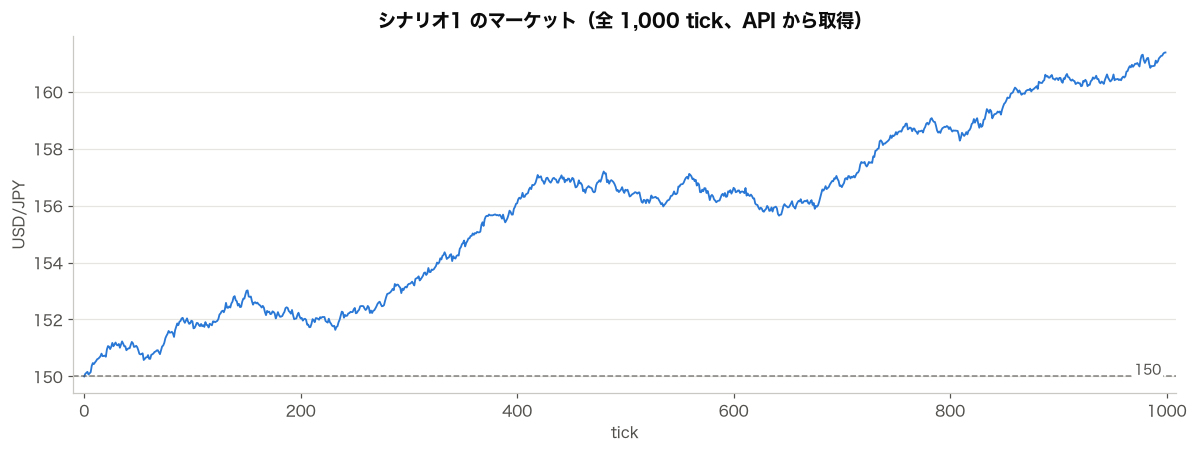

In [31]:
preview = run_api_session("TUTORIAL1", decide_fn=lambda prices: 0.0)
PRICES_1 = preview["rate"].to_numpy()
board.register(1, "TUTORIAL1", threshold=7.0, title="ゆっくり育つマーケット")

print(f"始値 {PRICES_1[0]:.3f} → 終値 {PRICES_1[-1]:.3f}"
      f"   (最安 {PRICES_1.min():.3f} / 最高 {PRICES_1.max():.3f})")
print(f"1ステップあたりの平均変化量: {np.diff(PRICES_1).mean():+.6f}")
price_plot(PRICES_1, "シナリオ1 のマーケット（全 1,000 tick、API から取得）",
           hline=150.0)

## 3.3 実装課題（Q3）

`Scenario1Strategy.decide` を実装してください。

**ヒント**
- `decide` は毎ステップ呼ばれ、返した値がその時点の目標ポジション比率 `[0, 1]` になります。
- 上の考察1〜4の答えが出ていれば、**このメソッドの本体は 1 行**です。
- 「いつ買うか／いつ売るか」を考え始めたら、考察3に戻ってください。

**合格ライン: リターン 7.00 %**

 シナリオ 1: ゆっくり育つマーケット
 戦略      : Buy & Hold
 最終資産      :      1,075,800 JPY
 リターン      :          7.580 %      (合格ライン 7.00 %)
 最大ドローダウン:         -0.986 %
 ✅ CLEAR


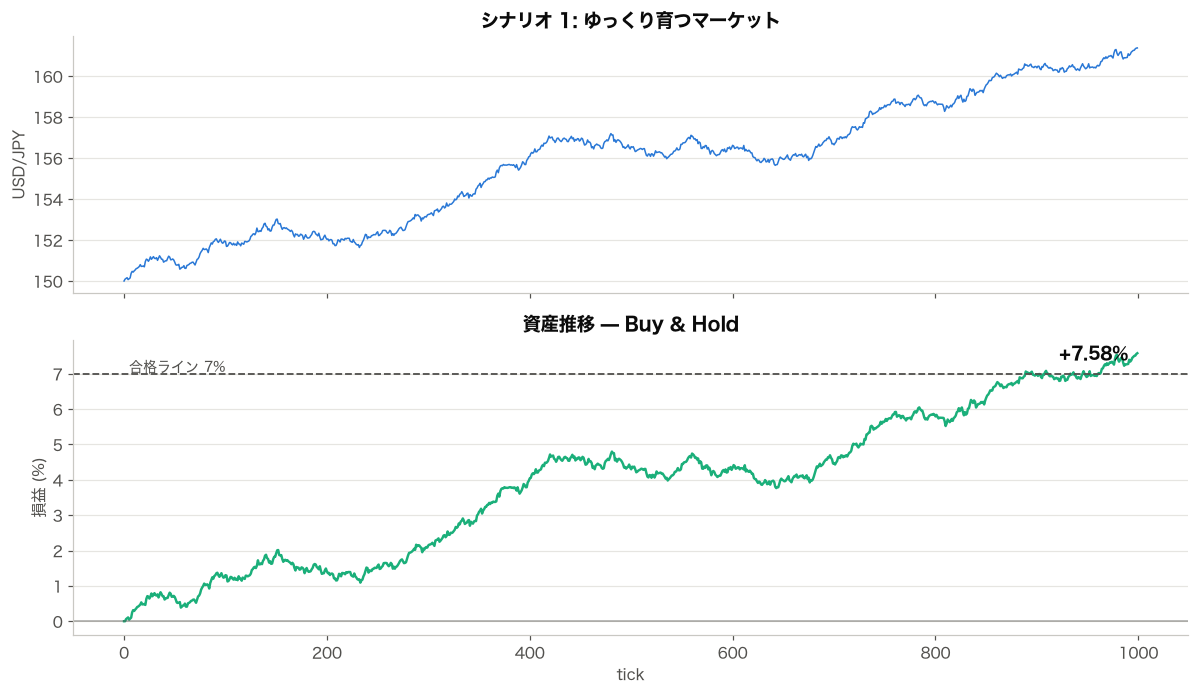

In [32]:
class Scenario1Strategy(Strategy):
    name = "Buy & Hold"

    def decide(self, t: int, prices: np.ndarray) -> float:
        return 1.0


res1 = board.submit(1, Scenario1Strategy())

# 解説（想定する思考プロセス）:
#   1. 期待変化量が正であることを、次の2点から言えれば十分:
#        (a) 上昇する確率のほうが高い          (0.61 > 0.39)
#        (b) 上昇側の分布のほうが中心が大きい  (0.0086 > 0.0032)
#      つまり「上に偏ったランダムウォーク」。
#
#      ※ 厳密な期待値は「絶対値を取っている」ぶん単純な差にはならない:
#          E[|N(mu, s^2)|] = s*sqrt(2/pi)*exp(-mu^2/(2*s^2)) + mu*(1 - 2*Phi(-mu/s))
#        上昇側 0.072137 / 下落側 0.071855 なので
#          E[dP] = 0.61*0.072137 - 0.39*0.071855 = +0.015980
#        （0.61*0.0086 - 0.39*0.0032 = +0.003998 は絶対値を無視した誤り）
#   2. 1,000 ステップ積み上がると理論上 +0.015980 * 1000 ≒ +16 円。
#      （実際の系列は 150.0 -> 161.4 = +11.4 円。単一シードぶんのばらつき）
#   3. 増分は互いに独立。過去の形は次の変化に一切影響しないので、
#      チャートを見てタイミングを計ることに情報上の意味がない。
#   4. よって「常に持ちっぱなし」= Buy & Hold が最適。 -> 7.585 %
#
#   ※ よくある誤答: 押し目買い・利確を入れる。
#     売買を挟むほど上昇に乗れない時間が生まれ、成績はむしろ下がる
#     （ゴールデンクロスの最良パラメータでも 6.19 % 止まりで閾値 7.0 % に届かない）。
#     ※ ゴールデンクロスは構造的に Buy & Hold の約82%しか取れない。閾値7.0%は
#       その 82%(=6.19%) と BH(7.59%) の隙間に置いてある。1,000 tick では
#       この隙間が上下 0.6〜0.8 pt しかなく、3シナリオ中もっとも余裕が薄い。


---
# Part 4. シナリオ 2

## 4.1 このマーケットの生成ルール

初期価格と長期均衡価格を

$$P_0 = \mu = 150$$

とし、価格 $P_t$ を次の漸化式で生成します。

$$P_t = P_{t-1} + \underbrace{\theta\,(\mu - P_{t-1})}_{\text{第1項}} + \underbrace{\sigma\, \varepsilon_t}_{\text{第2項}}$$

$$\theta = 0.1, \qquad \sigma = 1.1, \qquad \varepsilon_t \sim \mathcal{N}(0, 1) \ \ \text{(i.i.d.)}$$

### このルールから読み取れること

- **第2項**はただのランダムなノイズです。向きに偏りはありません。
- **第1項に注目してください。** $\mu = 150$ を基準に、
  - $P_{t-1} < \mu$（安いとき）→ $(\mu - P_{t-1}) > 0$ → **上向きの力**が働く
  - $P_{t-1} > \mu$（高いとき）→ $(\mu - P_{t-1}) < 0$ → **下向きの力**が働く
- しかもその力は **$\mu$ から離れているほど強く**なります（$\theta$ が強さ）。
- シナリオ1と違い、**過去の位置が次の変化の向きに影響します。**

## 4.2 考えてみてください

1. 価格が $\mu$ から大きく離れたとき、次に起きやすいのは「さらに離れる」「$\mu$ に戻る」のどちら？
2. $\mathbb{E}[P_t]$ は長期的にどこへ向かいますか？ このマーケットで **買ったまま放置**したらどうなりますか？
3. 「離れすぎ」を **プログラムで判定**するには、何と何を比べればよいでしょう？
   - $\mu$ の値を知らないふりをすると、**直近 $w$ 本の移動平均**が $\mu$ の推定値として使えます。
   - 「離れすぎ」の *ものさし* には、**直近 $w$ 本の標準偏差**が使えます。
4. ショートはできない（比率は `[0, 1]`）ことを踏まえると、
   「安すぎるとき」「高すぎるとき」にそれぞれどの比率を取るべきですか？

始値 150.000 → 終値 148.901   (最安 144.201 / 最高 157.982)
全期間の平均価格: 150.216


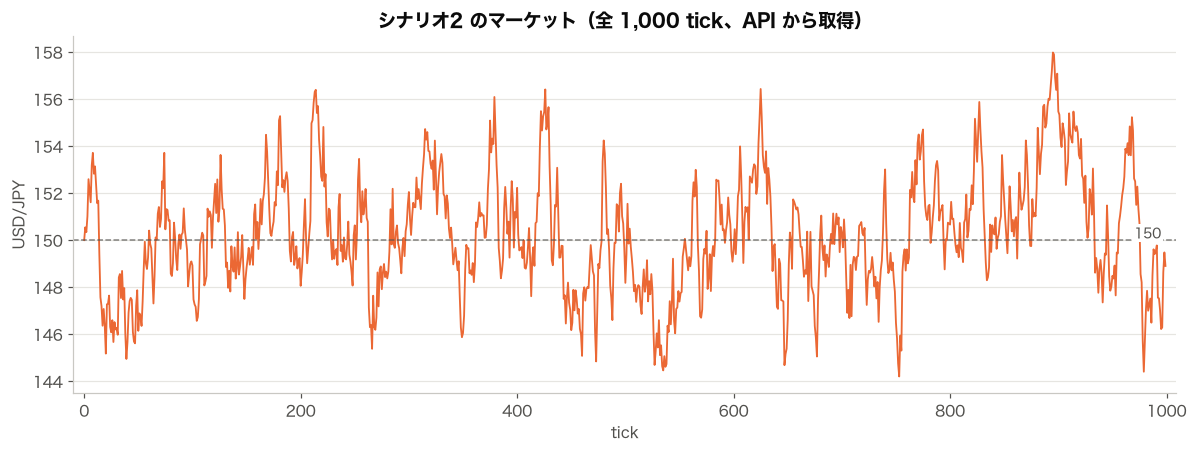

In [33]:
preview = run_api_session("TUTORIAL2", decide_fn=lambda prices: 0.0)
PRICES_2 = preview["rate"].to_numpy()
board.register(2, "TUTORIAL2", threshold=5.0, title="引き戻されるマーケット")

print(f"始値 {PRICES_2[0]:.3f} → 終値 {PRICES_2[-1]:.3f}"
      f"   (最安 {PRICES_2.min():.3f} / 最高 {PRICES_2.max():.3f})")
print(f"全期間の平均価格: {PRICES_2.mean():.3f}")
price_plot(PRICES_2, "シナリオ2 のマーケット（全 1,000 tick、API から取得）",
           color=SERIES[1], hline=150.0)

## 4.3 実装課題（Q4）

`Scenario2Strategy.decide` を実装してください。

**ヒント**
- `prices[-w:]` で直近 $w$ 本が取れます。`np.mean` / `np.std` が使えます。
- 「いま何σ離れているか」は
  $$z_t = \frac{P_t - \text{mean}(P_{t-w+1..t})}{\text{std}(P_{t-w+1..t})}$$
  で測れます。
- **$t$ が小さいうちは $w$ 本ぶんの履歴がありません。** その場合の返り値も決めてください。
- 標準偏差が 0 のときのゼロ除算に注意してください。
- 出発点として $w = 20$、しきい値 $2.0\sigma$ 程度から試すとよいです。合わなければ調整してください。

**合格ライン: リターン 5.00 %**

 シナリオ 2: 引き戻されるマーケット
 戦略      : Mean Reversion (Bollinger)
 最終資産      :      1,085,493 JPY
 リターン      :          8.549 %      (合格ライン 5.00 %)
 最大ドローダウン:         -2.796 %
 ✅ CLEAR


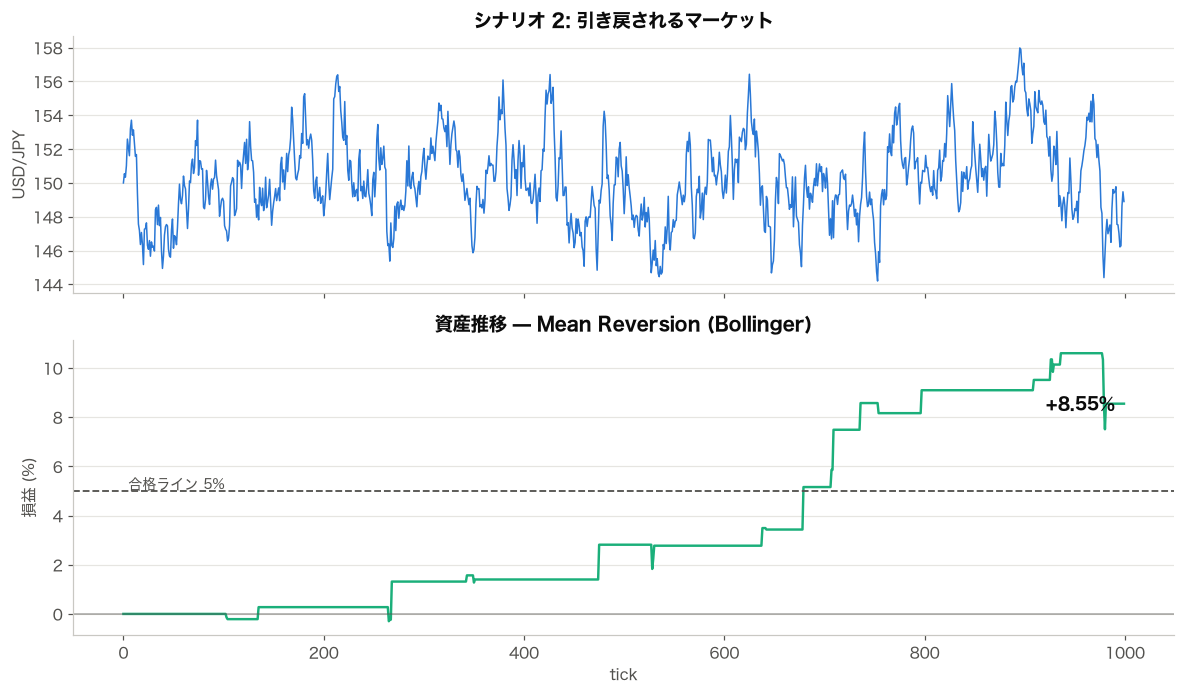

In [34]:
class Scenario2Strategy(Strategy):
    name = "Mean Reversion (Bollinger)"

    def __init__(self, window: int = 20, num_std: float = 2.0):
        self.window = window
        self.num_std = num_std

    def decide(self, t: int, prices: np.ndarray) -> float:
        if len(prices) < self.window:
            return 0.0                      # 履歴が足りないうちは何もしない
        w = prices[-self.window:]
        mean, std = w.mean(), w.std(ddof=1)
        if std == 0:
            return 0.0                      # ゼロ除算を避ける
        z = (prices[-1] - mean) / std
        if z < -self.num_std:
            return 1.0                      # 安すぎる -> 買う
        if z > self.num_std:
            return 0.0                      # 高すぎる -> 降りる（ショート不可のため）
        return 0.0


res2 = board.submit(2, Scenario2Strategy())

# 解説（想定する思考プロセス）:
#   1. 漸化式の第1項 theta*(mu - P) は、mu より下なら上向き・上なら下向きの力。
#      しかも mu から離れるほど強い -> 「離れすぎたら戻る」。
#   2. 長期的に E[P] -> mu = 150 なので、買ったまま放置しても儲からない
#      （実際 Buy & Hold は -0.733 %）。「戻る」動きそのものを取りに行く必要がある。
#   3. mu を知らない前提でも、直近 window 本の移動平均が mu の推定値になり、
#      移動標準偏差が「離れ具合」のものさしになる（= ボリンジャーバンド）。
#   4. ショート不可なので、取れるのは「安すぎ -> 全力ロング」「それ以外 -> 現金」の2択。
#
#   window=20, num_std=2.0 で 8.549 %（閾値 5.0 %）。
#   ※ num_std<=2.0 ならほぼ全ての window で通過する（実行可能な26通り中15通りが通過）。
#     num_std を大きくするほどバンドが広がってシグナルが出なくなり未達になる
#     （例: window=20, num_std=3.0 で +0.40 %）。
#   ※ そもそも window=5 で num_std>=2.0、window=10 で num_std=3.0 は
#     「絶対に発火しない」組み合わせ。窓内の1点が取りうる |z| の上限が
#     (w-1)/sqrt(w) なので、それを超える num_std は構造的に無効
#     （w=5 -> 1.79, w=10 -> 2.85, w=20 -> 4.25）。


---
# Part 5. シナリオ 3

## 5.1 このマーケットの生成ルール

このマーケットには **「レジーム（相場つき）」** という隠れ状態 $R_t \in \{+1, -1\}$ があります。

$$P_0 = 150$$

**レジームの遷移**（$L_t$ は現在のレジームが続いている長さ）:

$$
R_t =
\begin{cases}
-R_{t-1} & \text{確率 } p = \tfrac{1}{10} \ \text{ かつ } \ L_{t-1} > 40 \\[4pt]
\ \ R_{t-1} & \text{それ以外}
\end{cases}
$$

**価格の更新**:

$$P_t = P_{t-1} + \underbrace{R_t \cdot \kappa}_{\text{ドリフト}} + \underbrace{\sigma\,\varepsilon_t}_{\text{ノイズ}}$$

$$\kappa = 0.06, \qquad \sigma = 0.24, \qquad \varepsilon_t \sim \mathcal{N}(0,1)$$

### このルールから読み取れること

- $R_t = +1$ の間は **毎ステップ上向きのドリフト**がかかり続けます（$R_t = -1$ なら下向き）。
- レジームは **最低 41 ステップ**続き、平均するとおよそ **51 ステップ**続きます。
  **一度決まった向きはしばらく持続します。**
- ただし **$R_t$ は観測できません。** 見えるのは価格 $P_t$ だけです。
- シナリオ2は「離れたら戻る」でしたが、こちらは **「動き出したらしばらく同じ向きに進む」** です。

## 5.2 考えてみてください

1. シナリオ2と **真逆**の性質です。シナリオ2の戦略をこのデータに当てると、どうなると思いますか？
2. $R_t$ は直接見えません。**価格から現在のレジームを推定する**には？
   - ノイズ $\sigma = 0.24$ はドリフト $\kappa = 0.06$ の4倍あり、**1本の値動きだけでは向きは判断できません。**
   - ノイズをならすには **移動平均**が使えます。
3. 「上向きのレジームに入った」ことを検知したいとき、
   **期間の違う2本の移動平均**（短期と長期）を比べると何がわかりますか？
   - 短期線は直近の動きに素早く反応し、長期線はゆっくり動きます。
   - **短期線が長期線を下から上へ抜けた**とき、それは何を意味しますか？
4. レジームは平均するとおよそ51ステップ続きます。移動平均の期間は、これに対してどのくらいが妥当でしょう？

**合格ライン: リターン 5.00 %**

始値 150.000 → 終値 151.579   (最安 149.031 / 最高 161.719)


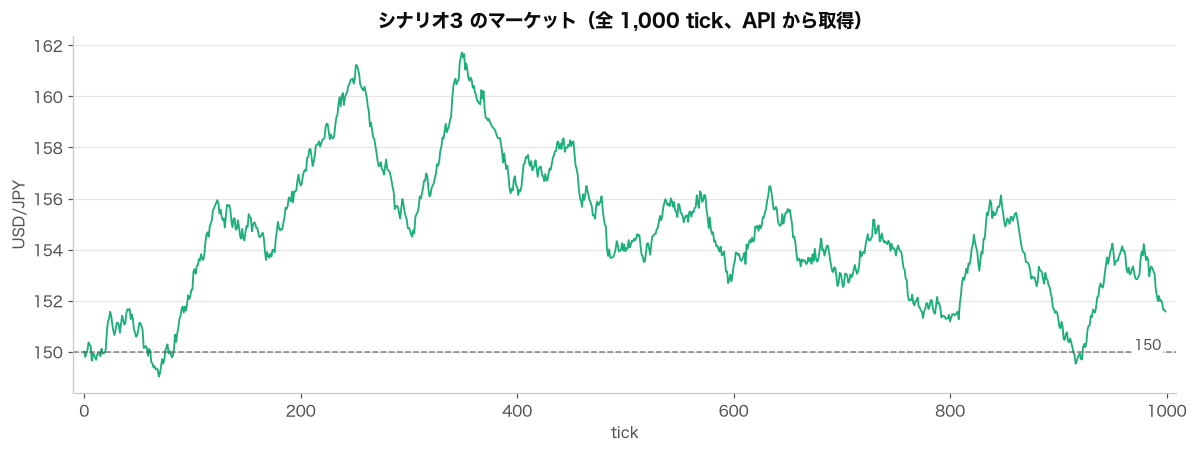

In [35]:
preview = run_api_session("TUTORIAL3", decide_fn=lambda prices: 0.0)
PRICES_3 = preview["rate"].to_numpy()
board.register(3, "TUTORIAL3", threshold=5.0, title="トレンドが続くマーケット")

print(f"始値 {PRICES_3[0]:.3f} → 終値 {PRICES_3[-1]:.3f}"
      f"   (最安 {PRICES_3.min():.3f} / 最高 {PRICES_3.max():.3f})")
price_plot(PRICES_3, "シナリオ3 のマーケット（全 1,000 tick、API から取得）",
           color=SERIES[2], hline=150.0)

## 5.3 実装課題（Q5）

`Scenario3Strategy.decide` を実装してください。

**ヒント**
- 短期・長期それぞれの移動平均は `np.mean(prices[-w:])` で計算できます。
- 履歴が長期側の期間に満たないうちは、まだ判断できません。
- ショート不可（`[0, 1]`）なので、「下向きだと判断したとき」にできるのは
  **保有分を売って現金に戻す**（比率 `0.0`）ところまでです。下落から利益を取ることはできません。
- 出発点として短期 5 / 長期 20 あたりから試してください。

**合格ライン: リターン 5.00 %**

 シナリオ 3: トレンドが続くマーケット
 戦略      : Golden Cross
 最終資産      :      1,136,547 JPY
 リターン      :         13.655 %      (合格ライン 5.00 %)
 最大ドローダウン:         -1.732 %
 ✅ CLEAR


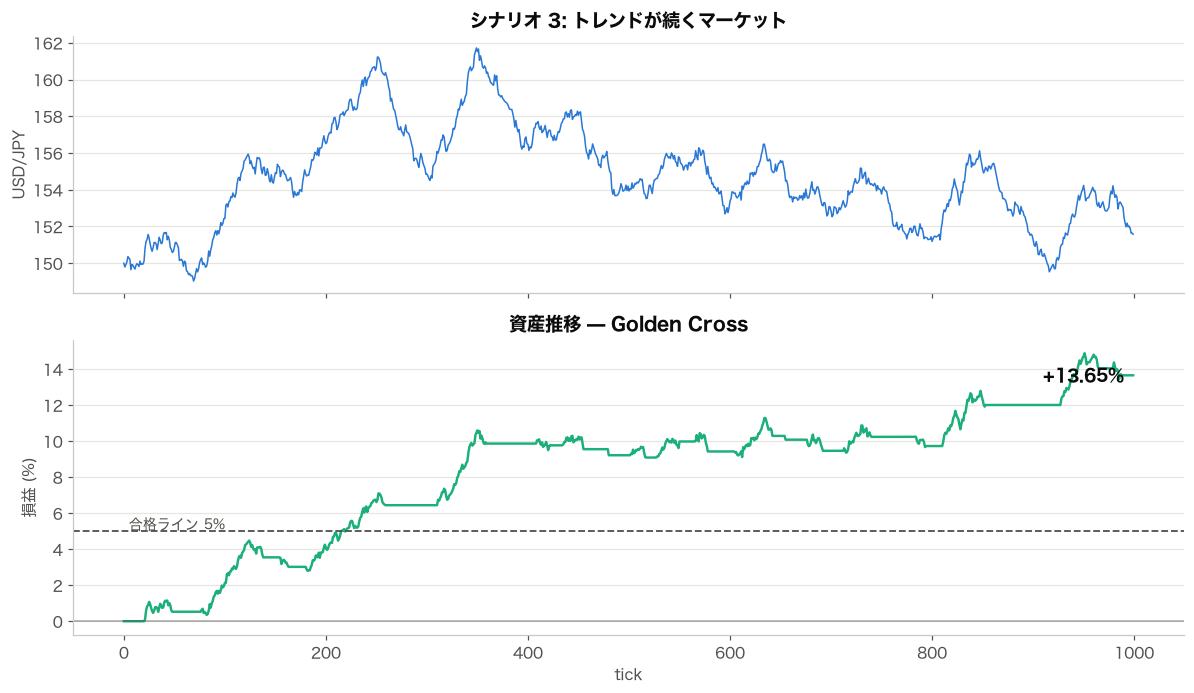

In [36]:
class Scenario3Strategy(Strategy):
    name = "Golden Cross"

    def __init__(self, short_window: int = 5, long_window: int = 20):
        self.short_window = short_window
        self.long_window = long_window

    def decide(self, t: int, prices: np.ndarray) -> float:
        if len(prices) < self.long_window:
            return 0.0                      # 長期線が引けるまで待つ
        short_ma = prices[-self.short_window:].mean()
        long_ma  = prices[-self.long_window:].mean()
        return 1.0 if short_ma > long_ma else 0.0


res3 = board.submit(3, Scenario3Strategy())

# 解説（想定する思考プロセス）:
#   1. レジーム R は +1/-1 のどちらかで、平均約51ステップ持続する。
#      「動き出したらしばらく同じ向きに進む」= シナリオ2と真逆の性質。
#   2. ただし R は観測できず、1ステップぶんのドリフト（0.06）は
#      ノイズ（0.24）の 1/4 しかない。
#      -> 1本の値動きだけでは向きを判定できない。ならすしかない。
#   3. 移動平均でノイズを平均化する。期間の違う2本を比べると、
#      短期線 > 長期線 = 「直近の平均が過去の平均を上回った」= 上向きレジームの推定。
#      この交差が golden cross。
#   4. ショート不可なので、下向き判定時は「持たない」（現金退避）が最善手。
#
#   5 / 20 で 13.655 %（閾値 5.0 %）。
#   ※ レジーム平均長（約51 tick）に対し、長期線はそれより十分短く取るのがコツ。
#     長期線を伸ばすほど反応が遅れ、20/60 では -1.09 %、50/200 では -6.59 % まで落ちる。
#     25通り中12通り（long<=30 の全て）が閾値 5.0 % を超える。


---
# Part 6. 総合評価 — 「万能の戦略」は存在するか

3つの戦略を **3つすべてのマーケット**に当ててみます。
提出時とは違い、ここでは **自分の戦略が「合わない」マーケットで何が起きるか**を見ます。

In [37]:
strategies = [Scenario1Strategy(), Scenario2Strategy(), Scenario3Strategy()]
markets = [("シナリオ1 (成長)", "TUTORIAL1"),
           ("シナリオ2 (回帰)", "TUTORIAL2"),
           ("シナリオ3 (トレンド)", "TUTORIAL3")]

def _return_pct(strategy, scenario):
    log = run_strategy_via_api(scenario, strategy)
    final = log["equity_jpy"].iloc[-1]
    return (final / INITIAL_JPY - 1.0) * 100.0

matrix = pd.DataFrame(
    [[_return_pct(s, scenario) for _, scenario in markets] for s in strategies],
    index=[s.name for s in strategies],
    columns=[m for m, _ in markets],
).round(3)

print("行 = 戦略 / 列 = マーケット、セル = リターン(%)\n")
try:
    display(matrix.style.format("{:+.3f}").background_gradient(cmap="RdYlGn", axis=None))
except (ImportError, AttributeError):          # jinja2 が無い環境へのフォールバック
    print(matrix.to_string())

## 議論してみてください

1. 行列の **対角成分**（自分のシナリオ用の戦略を、そのシナリオに当てたもの）が最大になっているはずです。
   **なぜ「万能に強い1つの戦略」が作れないのか**、生成ルールの言葉で説明してください。
2. 戦略を「合わないマーケット」に当てた列を見てください。
   - **ゴールデンクロス（シナリオ3の戦略）をシナリオ2に当てると、大きくマイナス**になります（想定解で約 -25%）。
     平均回帰するマーケットで「上に抜けた」と見て買うと、その直後の値動きはどちら向きになりやすいですか？
   - **シナリオ2の戦略（逆張り）をシナリオ3に当てる**と、大負けはしませんが BH に負けます（想定解で約 -2.5%、BH は約 +1.1%）。
     トレンドの途中で「高すぎる」と判断して降りると、その後の上昇分はどうなりますか？
3. 実際のマーケットは、この3つのどれか1つでずっと続くでしょうか？
   **レジームが切り替わることを前提にすると**、実務ではどんな設計が必要になりますか？

## 発展課題

- **A. 手数料の影響を見る。** API のシナリオ `TEST1`〜`TEST4` には手数料 0.1% が設定されています。
  `run_strategy_via_api` でこれらのシナリオに戦略を当て、取引回数の多い戦略ほど
  手数料でどれだけ不利になるかを調べてください。
- **B. 中間ポジション。** これまで比率は 0 か 1 でしたが、
  たとえば z スコアに比例させて `0.5 + z/4` のように連続的に変えると成績はどう変わりますか？
- **C. パラメータの過剰最適化。** シナリオ2の $w$ と $k$ を総当たりで最適化してみてください。
  次に `seed` を変えて別の系列を生成し、同じパラメータを当ててください。**成績は再現しますか？**
  これが *overfitting*（過剰最適化）です。
- **D. 実データで検証。** `run_strategy_via_api("TEST1", strategy)` のように実際の過去レートを使う
  シナリオに3つの戦略を当ててください。人工データほどきれいに勝てますか？

---
# 付録: 講師用メモ（受講者に配る際は削除してください）

## 想定解の置き場所

**模範解答は各穴埋めセルの末尾に、コメントアウトした形で入れてあります。**
`【解答例 / 講師用】` で検索してください。コード本体だけでなく、
「そのデータ生成ルールから、なぜその戦略に行き着くのか」という**想定する思考プロセス**と、
よくある誤答も併記してあります。

| 問 | セル | 想定解 | 成績 |
|---|---|---|---|
| Q1-1 | `get_health` | `HTTP.get` + `raise_for_status` | — |
| Q1-2 | `start_session` | `HTTP.post`（ボディなし・パスに埋め込み） | — |
| Q1-3 | `step` | `HTTP.post(..., json=payload)` | — |
| Q1-4 | `run_api_session` | `get_rate` で現在のレートを取得 → `decide_fn` → `to_exchange_requests` → `step` → `balances` 更新 | — |
| Q3 | シナリオ1 | Buy & Hold（`return 1.0`） | 7.580 % |
| Q4 | シナリオ2 | 逆張り / ボリンジャーバンド (20, 2.0) | 8.549 % |
| Q5 | シナリオ3 | ゴールデンクロス (5, 20) | 13.655 % |

> **配布時の作業:** 各セルの `【解答例 / 講師用】` ブロックと、この付録セルを削除してください。

## 閾値の設計根拠

各シナリオの閾値は、**3つの戦略ファミリーを広いパラメータ格子で総当たりして**決めてあります。
「意図した考え方でのみ超えられる」ことを確認済みです。

**合格ラインはシナリオ1のみ 7.0 %、シナリオ2・3 は 5.0 %** です（各シナリオ 1,000 tick）。

| シナリオ | 閾値 | Buy&Hold | 逆張り (26通り) | ゴールデンクロス (25通り) |
|---|---|---|---|---|
| 1 | 7.0 % | **7.585 ✅** | 0/26 通過 (最良 1.94) | 0/25 通過 (最良 6.19) |
| 2 | 5.0 % | −0.733 ❌ | **15/26 通過** (想定解 8.55) | 0/25 通過 (最良 −8.95) |
| 3 | 5.0 % | 1.053 ❌ | 0/26 通過 (最良 0.76) | **12/25 通過** (想定解 13.66) |

逆張りの格子は 30 通りのうち 4 通り（`w=5, k>=2.0` と `w=10, k=3.0`）が
**構造的に発火不可能**（窓内の |z| の上限 `(w-1)/sqrt(w)` を超える）なため、
実行可能な 26 通りを分母にしています。

> **シナリオ1の注意（1,000 tick で最も影響を受けた箇所）:**
> ゴールデンクロスは構造的に Buy & Hold の**約82%**を取ります。
> 43,200 tick 版ではこの比率が 62% だったため 3シナリオとも 5.0 % で統一できましたが、
> tick 数が減るとゴールデンクロスの取りこぼしが積み上がらず、差が詰まります。
> 閾値 7.0 % は `6.19 %`（順張り系の最良）と `7.585 %`（Buy & Hold）の隙間に置いてあり、
> **余裕は上下 0.6〜0.8 pt しかありません**。
> **`seed` を変更するとこの関係は容易に崩れます。必ず再検証してください（`seed=42` 前提）。**

## 運用上の注意

- **API サーバ**: 共有サーバ `http://os3-389-27987.vs.sakura.ne.jp` は接続は受け付けるものの
  応答が返らない状態を確認しています（2026-07-30 時点）。**Dev Container でのローカル起動を前提**にしてください。
- **`userId`**: `TraderFinder` で DB を引くため、**未登録のIDではセッションを開始できません**。
  初期投入されているのは `testuser`（type=`test`）ほかです。事前に配布IDを登録しておいてください。
- **TUTORIAL1/2/3 がサーバに登録済みであること**: Part 3〜5 は `TUTORIAL1`/`TUTORIAL2`/`TUTORIAL3`
  を API 経由で叩きます。演習前に、これらのシナリオと対応するレートが対象サーバへ投入済みであることを
  確認してください（投入手順は内部ドキュメントを参照）。未投入だと Part 3 以降が全滅します。
- **所要時間の目安**: Part 1 が 30〜45分、各シナリオが 20〜40分。